# Unit 5 — 05: Experiment Tracking with MLflow (and W&B Overview)

**What you will do:** Run 4 experiments with different hyperparameters, log them to MLflow, query results programmatically, load a saved model, and compare MLflow vs Weights & Biases.

**Why it matters:** Without experiment tracking, you cannot reproduce a model from 3 months ago, compare runs fairly, or explain to stakeholders why you chose a specific model.

**How to run:** Python 3.10+. `pip install mlflow scikit-learn` first. Run cells in order.

---

## Section 1 — Why Experiment Tracking

Consider a team that trains 50 models over two months without tracking:

- A model deployed in production gives wrong predictions. Which training run produced it?
- A new team member wants to beat the current model. What hyperparameters were tried?
- A regulator asks: what data was this model trained on? Nobody knows.

Experiment tracking solves all three by making every training run a first-class artifact:
- **Parameters** (what you set before training)
- **Metrics** (what you measured after training)
- **Artifacts** (the model file, plots, feature importance)
- **Tags** (dataset version, environment, team)
- **Code version** (git commit hash)

## Section 2 — MLflow Core Concepts

| Concept | Description |
|---|---|
| **Experiment** | A named group of related runs (e.g., "iris-classifier") |
| **Run** | A single training execution within an experiment |
| **Parameters** | Inputs to the run (hyperparameters, config) |
| **Metrics** | Outputs (accuracy, loss, latency) — can be logged per step |
| **Artifacts** | Files produced (model, plots, confusion matrix) |
| **Tracking URI** | Where MLflow stores data (local file, SQLite, remote server) |

## Section 3 — Set Up MLflow Tracking

In [1]:
import pathlib
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Use SQLite as a local tracking backend — no server needed
DB_PATH = pathlib.Path("/tmp/mlruns.db")
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")

EXPERIMENT_NAME = "iris-classifier"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: sqlite:///{DB_PATH}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"MLflow version: {mlflow.__version__}")

# Load data
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nData: {len(X_train)} train, {len(X_test)} test samples")

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
2026/06/14 07:42:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/14 07:42:01 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger lim

MLflow tracking URI: sqlite:////tmp/mlruns.db
Experiment: iris-classifier
MLflow version: 2.17.2

Data: 120 train, 30 test samples


## Section 4 — Run 4 Experiments with Different Hyperparameters

In [2]:
import time
from typing import Dict, Any

experiments = [
    {
        "run_name": "LogisticRegression_C1",
        "model": LogisticRegression(C=1.0, max_iter=200),
        "params": {"model_type": "LogisticRegression", "C": 1.0, "max_iter": 200},
    },
    {
        "run_name": "RandomForest_50",
        "model": RandomForestClassifier(n_estimators=50, random_state=42),
        "params": {"model_type": "RandomForest", "n_estimators": 50, "random_state": 42},
    },
    {
        "run_name": "RandomForest_100",
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "params": {"model_type": "RandomForest", "n_estimators": 100, "random_state": 42},
    },
    {
        "run_name": "GradientBoosting_50",
        "model": GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42),
        "params": {"model_type": "GradientBoosting", "n_estimators": 50, "learning_rate": 0.1},
    },
]

logged_run_ids = []

print(f"{'Run':<25} {'Accuracy':>10} {'F1 (macro)':>12} {'Time (s)':>10}")
print("-" * 62)

for exp in experiments:
    with mlflow.start_run(run_name=exp["run_name"]) as run:
        # Log parameters
        mlflow.log_params(exp["params"])
        mlflow.set_tag("dataset", "iris")
        mlflow.set_tag("framework", "sklearn")

        # Train
        t0 = time.perf_counter()
        exp["model"].fit(X_train, y_train)
        train_time = time.perf_counter() - t0

        # Evaluate
        y_pred = exp["model"].predict(X_test)
        accuracy = float(accuracy_score(y_test, y_pred))
        f1 = float(f1_score(y_test, y_pred, average="macro"))

        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("training_time_s", round(train_time, 3))

        # Log model artifact
        mlflow.sklearn.log_model(exp["model"], artifact_path="model")

        logged_run_ids.append(run.info.run_id)
        print(f"{exp['run_name']:<25} {accuracy:>10.4f} {f1:>12.4f} {train_time:>10.3f}")

print(f"\nLogged {len(logged_run_ids)} runs to experiment '{EXPERIMENT_NAME}'.")

Run                         Accuracy   F1 (macro)   Time (s)
--------------------------------------------------------------


2026/06/14 07:42:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression_C1         1.0000       1.0000      0.006


2026/06/14 07:42:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest_50               1.0000       1.0000      0.015


2026/06/14 07:42:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest_100              1.0000       1.0000      0.029


2026/06/14 07:42:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


GradientBoosting_50           1.0000       1.0000      0.030

Logged 4 runs to experiment 'iris-classifier'.


## Section 5 — Query Results Programmatically

All runs in experiment:
  tags.mlflow.runName  metrics.accuracy  metrics.f1_macro  metrics.training_time_s  params.model_type
  GradientBoosting_50               1.0               1.0                    0.030   GradientBoosting
     RandomForest_100               1.0               1.0                    0.029       RandomForest
      RandomForest_50               1.0               1.0                    0.015       RandomForest
LogisticRegression_C1               1.0               1.0                    0.006 LogisticRegression

Best run: GradientBoosting_50
  Run ID:   604adf4f69094b8391cd3817b67c554f
  Accuracy: 1.0000


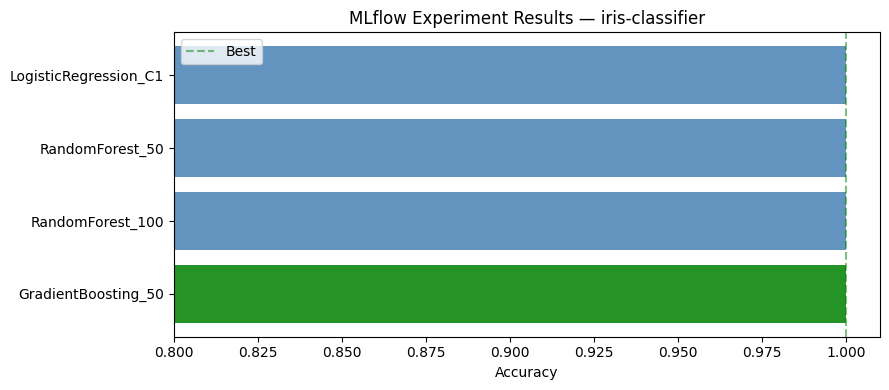

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Search all runs in the experiment
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

# Show key columns
display_cols = ["tags.mlflow.runName", "metrics.accuracy", "metrics.f1_macro",
                "metrics.training_time_s", "params.model_type"]
print("All runs in experiment:")
print(runs_df[display_cols].to_string(index=False))

# Find the best run by accuracy
best_run = runs_df.sort_values("metrics.accuracy", ascending=False).iloc[0]
best_run_id = best_run["run_id"]
best_accuracy = best_run["metrics.accuracy"]
best_name = best_run["tags.mlflow.runName"]

print(f"\nBest run: {best_name}")
print(f"  Run ID:   {best_run_id}")
print(f"  Accuracy: {best_accuracy:.4f}")

# Plot comparison
run_names = runs_df["tags.mlflow.runName"].tolist()
accuracies = runs_df["metrics.accuracy"].tolist()
colors = ["green" if r == best_name else "steelblue" for r in run_names]

plt.figure(figsize=(9, 4))
plt.barh(run_names, accuracies, color=colors, alpha=0.85)
plt.axvline(max(accuracies), color="green", linestyle="--", alpha=0.5, label="Best")
plt.xlabel("Accuracy")
plt.title("MLflow Experiment Results — iris-classifier")
plt.xlim(0.8, 1.01)
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/mlflow_results.png", dpi=72)
plt.show()

## Section 6 — Load a Model from MLflow

In [4]:
# Load the best model back from the MLflow artifact store
model_uri = f"runs:/{best_run_id}/model"
print(f"Loading model from: {model_uri}")

loaded_model = mlflow.sklearn.load_model(model_uri)
print(f"Loaded: {type(loaded_model).__name__}")

# Verify it produces identical predictions
y_pred_loaded = loaded_model.predict(X_test)
accuracy_loaded = float(accuracy_score(y_test, y_pred_loaded))
print(f"Accuracy from loaded model: {accuracy_loaded:.4f} (matches logged: {accuracy_loaded == best_accuracy})")

# Predict a single sample
sample = X_test[0].reshape(1, -1)
prediction = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]
print(f"\nSample prediction: {iris.target_names[prediction]} (confidence: {proba.max():.3f})")

Loading model from: runs:/604adf4f69094b8391cd3817b67c554f/model
Loaded: GradientBoostingClassifier
Accuracy from loaded model: 1.0000 (matches logged: True)

Sample prediction: versicolor (confidence: 0.994)


## Section 7 — Weights & Biases Overview

W&B is a cloud-hosted experiment tracking platform. The API is similar to MLflow but it offers richer real-time dashboards and team collaboration features.

**Note:** W&B requires an API key (`wandb login`). The code below shows the pattern — run it only if you have a W&B account.

In [5]:
# W&B equivalent of the MLflow experiment above
# Requires: pip install wandb && wandb login
try:
    import wandb

    # Initialize a run
    wandb.init(
        project="iris-classifier",
        name="RandomForest_100",
        config={"n_estimators": 100, "random_state": 42},  # params
    )

    # Log metrics (can be called per epoch/step for deep learning)
    wandb.log({"accuracy": 0.9667, "f1_macro": 0.9667, "training_time_s": 0.08})

    # Save an artifact
    # artifact = wandb.Artifact("iris-model", type="model")
    # artifact.add_file("/tmp/model.pkl")
    # wandb.log_artifact(artifact)

    wandb.finish()
    print("W&B run logged successfully.")

except ImportError:
    print("W&B not installed (pip install wandb). Showing code pattern above.")
except Exception as e:
    print(f"W&B error (likely not logged in): {e}")

print("""
MLflow vs Weights & Biases comparison:

| Feature              | MLflow                    | W&B                        |
|----------------------|---------------------------|----------------------------|
| Hosting              | Self-hosted or Databricks | Cloud (wandb.ai)           |
| Cost                 | Open-source, free         | Free tier, paid for teams  |
| Setup                | pip install mlflow        | pip install wandb + login  |
| Real-time dashboards | Limited                   | Excellent                  |
| Team collaboration   | Via shared server         | Built-in                   |
| Hyperparameter sweep | Manual                    | wandb.sweep() built-in     |
| Data privacy         | Full control              | Cloud (data leaves machine)|
| Best for             | On-prem, regulated envs   | Research, fast iteration   |
""")

W&B not installed (pip install wandb). Showing code pattern above.

MLflow vs Weights & Biases comparison:

| Feature              | MLflow                    | W&B                        |
|----------------------|---------------------------|----------------------------|
| Hosting              | Self-hosted or Databricks | Cloud (wandb.ai)           |
| Cost                 | Open-source, free         | Free tier, paid for teams  |
| Setup                | pip install mlflow        | pip install wandb + login  |
| Real-time dashboards | Limited                   | Excellent                  |
| Team collaboration   | Via shared server         | Built-in                   |
| Hyperparameter sweep | Manual                    | wandb.sweep() built-in     |
| Data privacy         | Full control              | Cloud (data leaves machine)|
| Best for             | On-prem, regulated envs   | Research, fast iteration   |



## Summary

What experiment tracking solves:
- **Reproducibility** — every run is logged with parameters, metrics, and the exact model artifact
- **Comparison** — `mlflow.search_runs()` lets you query and rank all experiments programmatically
- **Auditability** — you can always answer "which run produced the model currently in production?"
- **Rollback** — you can load any previous model artifact in one line

MLflow vs W&B: use MLflow when you need on-premises control or are in a regulated environment; use W&B when you want rich dashboards and team features with minimal setup.

## Self-Check (answer before scrolling back up)

1. **What is the difference between an MLflow 'experiment' and a 'run'?**  
   An experiment is a named container for related runs — like a project folder. A run is a single execution within that experiment — like one training job. You can have hundreds of runs inside one experiment.

2. **How do you load a specific model version from MLflow?**  
   Use `mlflow.sklearn.load_model(f"runs:/{run_id}/model")`. You need the `run_id`, which you can find by querying `mlflow.search_runs()` and filtering or sorting by metric.

3. **When would you prefer W&B over MLflow?**  
   When you need real-time training dashboards (especially for deep learning with per-epoch metrics), when your team collaborates remotely and needs shared experiment views, or when you want the built-in hyperparameter sweep feature (`wandb.sweep`). For on-premises data requirements or regulated industries, MLflow's self-hosted option is safer.